<a href="https://colab.research.google.com/github/poprostuVEX/Kurs-AI/blob/main/lekcja87.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
import math

In [ ]:
df = sns.load_dataset('iris')
print(df.head())
print(len(df))
print(len(df.columns))
print(df['species'].value_counts())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
150
5
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


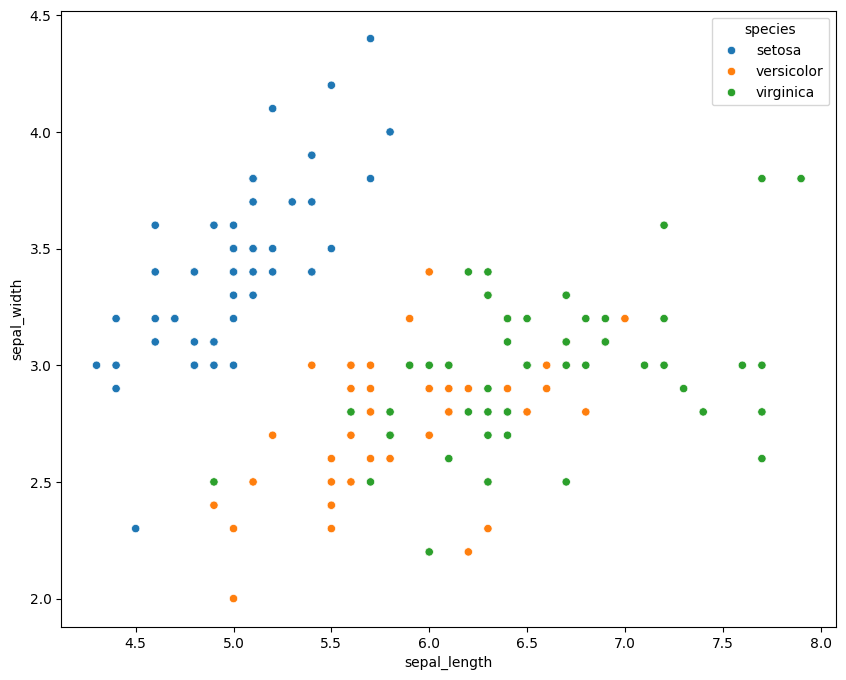

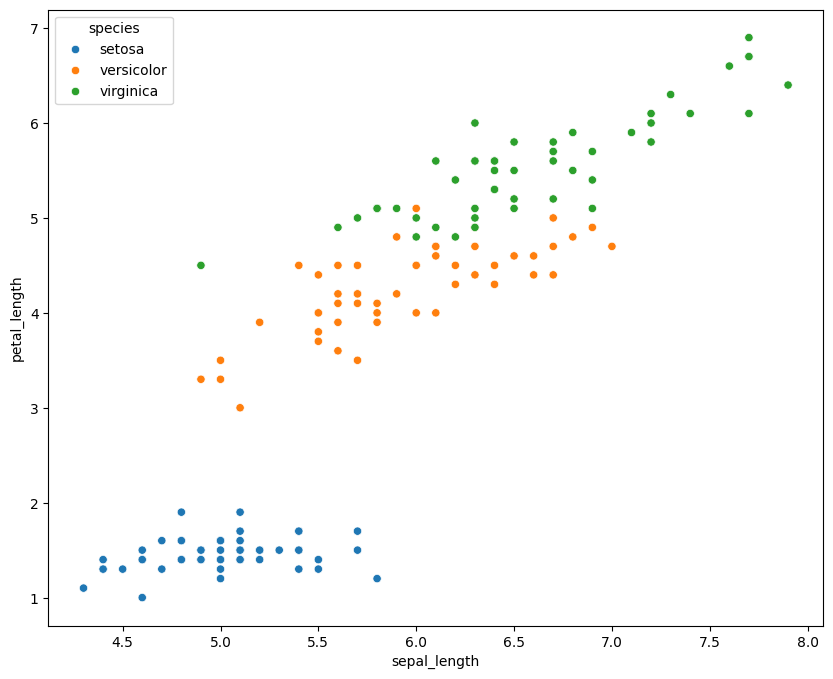

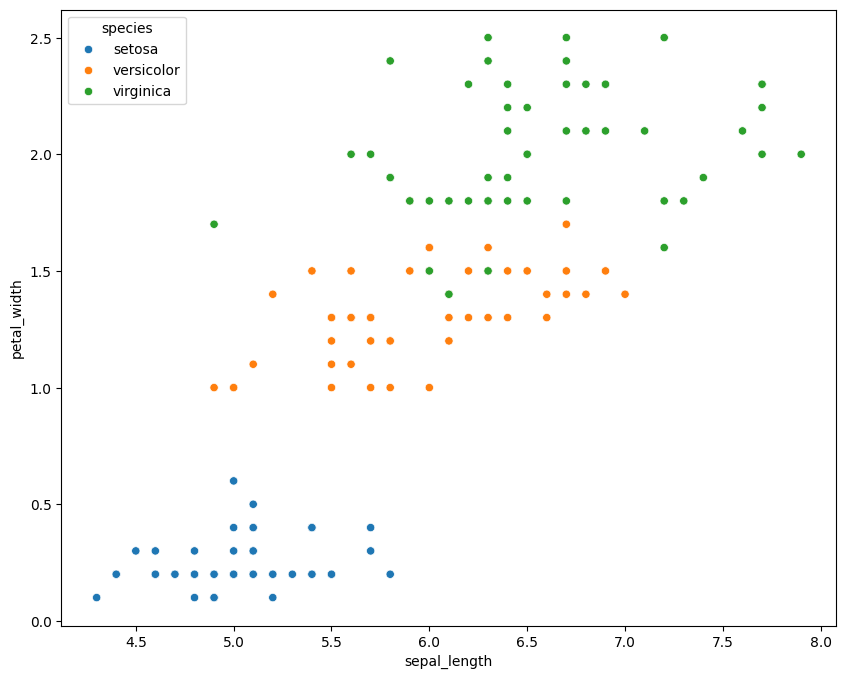

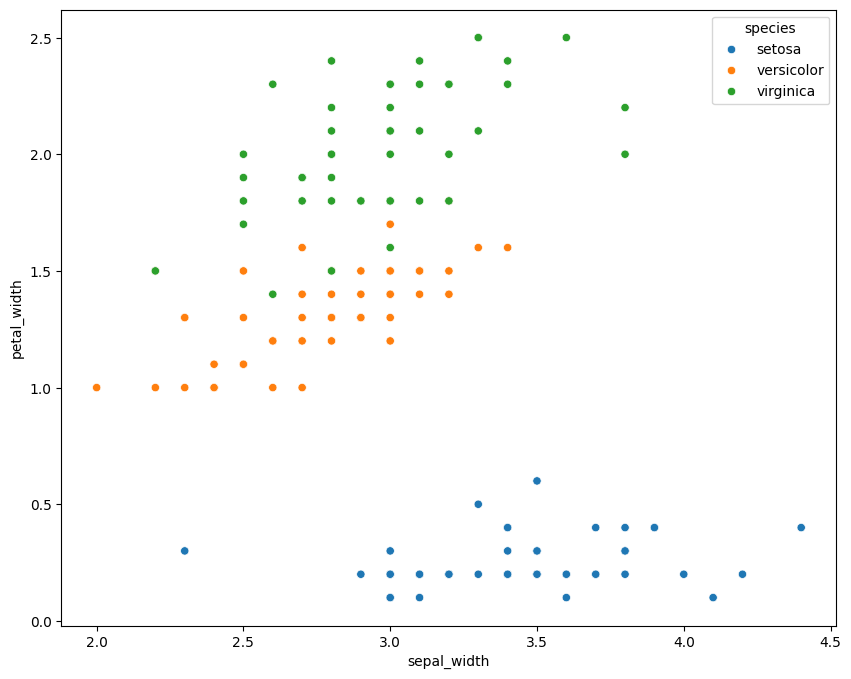

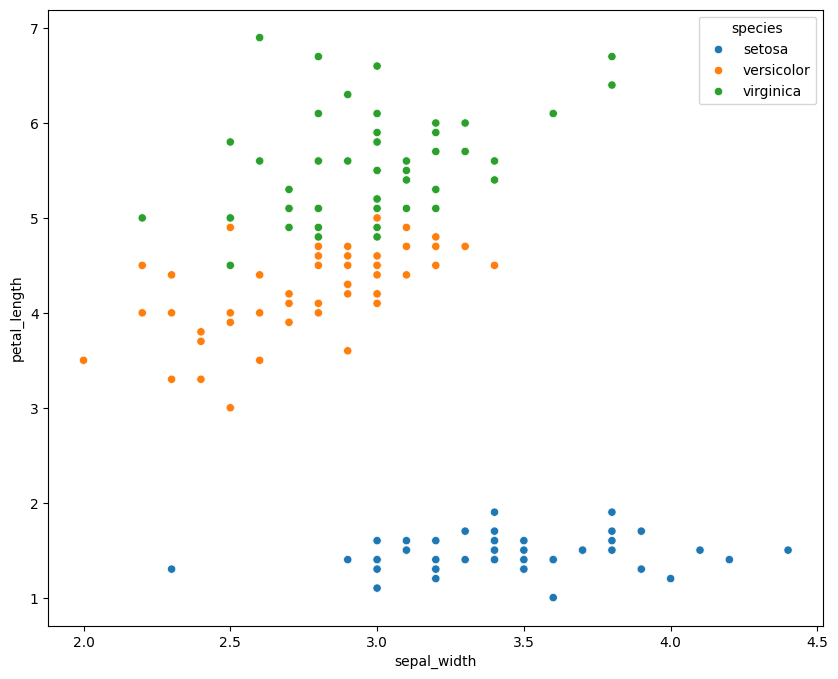

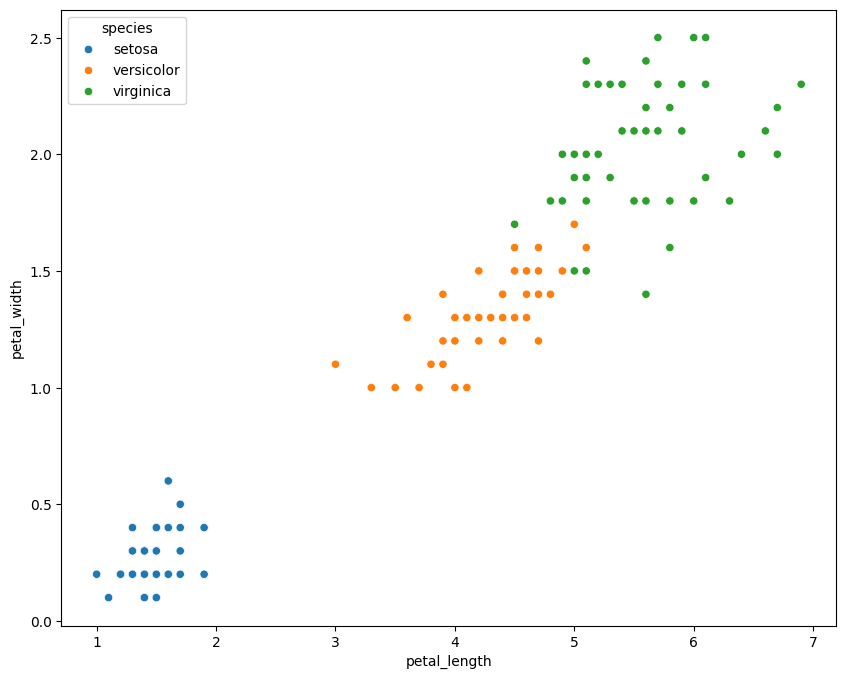

In [ ]:
feature_pairs = [
 ('sepal_length', 'sepal_width'),
 ('sepal_length', 'petal_length'),
 ('sepal_length', 'petal_width'),
 ('sepal_width', 'petal_width'),
 ('sepal_width', 'petal_length'),
 ('petal_length', 'petal_width')
]
# Polskie nazwy cech
feature_names_pl = {
 'sepal_length': 'Długość działki kielicha (cm)',
 'sepal_width': 'Szerokość działki kielicha (cm)',
 'petal_length': 'Długość płatka (cm)',
 'petal_width': 'Szerokość płatka (cm)'
}
for x_feature,y_feature in feature_pairs:
  plt.figure(figsize=(10,8))

  scater = sns.scatterplot(data = df, x=x_feature,y=y_feature,hue='species')


In [ ]:
X = df.drop(columns='species').values
Y = df['species'].values
x_train, x_test, y_train, y_test = train_test_split(
 X, Y, test_size=0.2, random_state=42, shuffle=True, stratify=Y
)

In [ ]:
def calculate_distance(point1, point2):
  distance =0
  for i in range (len(point1)):
    distance +=(point1[i]-point2[i])**2
  return math.sqrt(distance)

def knn_classifier(X_train, y_train, X_test, k):
    predictions = []
    for test_point in X_test:
        distances = []
        # Obliczenie odległości do wszystkich punktów treningowych
        for i, train_point in enumerate(X_train):
            dist = calculate_distance(test_point, train_point)
            distances.append((dist, y_train[i]))

        # Sortowanie według odległości (pierwszy element krotki)
        distances.sort(key=lambda x: x[0])

        # Wybranie k najbliższych sąsiadów na podstawie głosów
        neighbors= distances[:k]
        votes={}
        for _, label in neighbors:
          if label in votes:
            votes[label]+=1
          else:
            votes[label]=1


        # Znalezienie etykiety z największą liczbą głosów
        max_votes = 0
        most_common_label = None
        for label, count in votes.items():
            if count > max_votes:
                max_votes = count
                most_common_label = label


        predictions.append(most_common_label)

    return predictions


In [ ]:
def test_KNN(k):
  predictions = knn_classifier(x_train,y_train,x_test,k)
  for i ,prediction in enumerate(predictions):
    predictions = np.array(predictions)
    correct = np.sum(predictions == y_test)
    accuracy = correct / len(y_test)
    print(f"\nDokładność algorytmu KNN dla k = {k}: {accuracy:.2f}")
    print(f"Próbka {i+1}: Predykcja = {prediction}, Rzeczywisty = {y_test[i]}")
test_KNN(3)


Dokładność algorytmu KNN dla k = 3: 1.00
Próbka 1: Predykcja = setosa, Rzeczywisty = setosa

Dokładność algorytmu KNN dla k = 3: 1.00
Próbka 2: Predykcja = virginica, Rzeczywisty = virginica

Dokładność algorytmu KNN dla k = 3: 1.00
Próbka 3: Predykcja = versicolor, Rzeczywisty = versicolor

Dokładność algorytmu KNN dla k = 3: 1.00
Próbka 4: Predykcja = versicolor, Rzeczywisty = versicolor

Dokładność algorytmu KNN dla k = 3: 1.00
Próbka 5: Predykcja = setosa, Rzeczywisty = setosa

Dokładność algorytmu KNN dla k = 3: 1.00
Próbka 6: Predykcja = versicolor, Rzeczywisty = versicolor

Dokładność algorytmu KNN dla k = 3: 1.00
Próbka 7: Predykcja = setosa, Rzeczywisty = setosa

Dokładność algorytmu KNN dla k = 3: 1.00
Próbka 8: Predykcja = setosa, Rzeczywisty = setosa

Dokładność algorytmu KNN dla k = 3: 1.00
Próbka 9: Predykcja = virginica, Rzeczywisty = virginica

Dokładność algorytmu KNN dla k = 3: 1.00
Próbka 10: Predykcja = versicolor, Rzeczywisty = versicolor

Dokładność algorytmu KNN